# Fixed Income Strategy and Relative Value Analysis

This notebook implements quantitative tools for fixed income portfolio management:

* top-down yield curve analysis
* asset allocation signals
* relative value identification
* pair trading strategies
* statistical arbitrage signals

The framework progresses from simple (EUR government bonds) to complex
(multi-currency, cross-asset) as the analytical toolkit builds up.

**Contents:**
1. Top-down analysis -- yield curve shape and macro signals
2. EUR government bond relative value -- z-spread and DV01 adjusted spreads
3. Curve trades -- 2s10s, 5s30s slope and curvature
4. Cross-country spreads -- Bund vs OAT vs BTP
5. Pair trading -- statistical framework and signal generation
6. EUR IG credit -- adding the credit dimension
7. Multi-currency relative value -- EUR vs USD rates
8. Asset allocation signals -- combining indicators

**Regulatory context:**
- FRTB SA -- GIRR delta, CSR-NS for IG bonds
- UCITS -- global exposure limits for derivative-based strategies
- AIFMD -- leverage monitoring for relative value funds

---
*Notebook QRE-72 | Module 1 -- Yield Curves and Asset Pricing*

In [1]:
from quant_risk.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from quant_risk.instruments.bond import Bond

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

base loaded
OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-05-04
Valuation date : March 24th, 2026
Calendar       : TARGET
asset pricing loaded


In [2]:
# correcting date from OIS curve to match NSS curve
if nss_curve.valuation_date != ois_curve.valuation_date:
    latest_nss = nss_curve   # keep the live one for reference
    nss_curve  = NSSCurve.from_ecb(rating='AAA', last_n=60, date=ois_curve.valuation_date)
    print(f"NSS aligned: {nss_curve.valuation_date} (latest available: {latest_nss.valuation_date})")
else:
    print(f"NSS and OIS already aligned: {nss_curve.valuation_date}")
    
print(f"OIS valuation date: {ois_curve.valuation_date}")
print(f"NSS valuation date: {nss_curve.valuation_date}")

NameError: name 'NSSCurve' is not defined

## 1. Top-Down Analysis -- Yield Curve Shape and Macro Signals

Top-down analysis in fixed income starts with the yield curve, the term structure of interest rates. The shape of the curve encodes:
1. market's expectations about future short rates
2. risk premium demanded for holding longer-dated bonds

**Three dimensions of the yield curve:**

<small> 

| Dimension | Measure | Economic meaning |
|-----------|---------|------------------|
| Level | Average rate across tenors | Overall cost of money, central bank stance |
| Slope | Long rate minus short rate | Growth and inflation expectations |
| Curvature | Mid-point vs average of short and long | Convexity demand, risk-off flows |

</small> 

**Slope as a macro signal:**
1. steep curve (long rates >> short rates) 
* signals the market expects
economic growth and rising rates
* bullish environment, position for
flattening. 

2. An inverted curve (short rates > long rates) 
* signals recession fear or central bank overtightening. 
* Historically one of the most reliable recession predictors.

**Curvature (butterfly) as a positioning signal:**
The butterfly spread measures whether the mid-point of the curve is
cheap or rich relative to the two wings:

$$Butterfly = 2 \times r_{5Y} - r_{2Y} - r_{10Y}$$

Positive butterfly: the belly (5Y) is rich relative to wings -- sell
the belly, buy the wings. Negative: belly is cheap -- buy the belly.

In [ ]:
# ── extract key rates from the OIS curve ──────────────────────────────────────
# The OIS curve gives us the risk-free EUR rate at any tenor.
# We read off standard tenors to analyse curve shape.

key_tenors = {
    '3M': 0.25, '6M': 0.5, '1Y': 1.0, '2Y': 2.0,
    '3Y': 3.0,  '5Y': 5.0, '7Y': 7.0, '10Y': 10.0,
    '15Y': 15.0, '20Y': 20.0, '30Y': 30.0
}

ois_rates = {label: ois_curve.zero_rate(T) for label, T in key_tenors.items()}

# ── three PCA factors: level, slope, curvature ────────────────────────────────
# Level: average rate across all tenors
# Slope: 10Y minus 2Y (most common definition)
# Curvature (butterfly): 2 * 5Y - 2Y - 10Y

level      = np.mean(list(ois_rates.values()))
slope_2s10s = ois_rates['10Y'] - ois_rates['2Y']
slope_5s30s = ois_rates['30Y'] - ois_rates['5Y']
butterfly   = 2 * ois_rates['5Y'] - ois_rates['2Y'] - ois_rates['10Y']

print(f"EUR OIS Curve Analysis -- {valuation_date}")
print(f"\nCurve shape factors:")
print(f"  Level (average):     {level:.3f}%")
print(f"  Slope 2s10s:         {slope_2s10s:+.3f}% ({slope_2s10s*100:.1f}bps)")
print(f"  Slope 5s30s:         {slope_5s30s:+.3f}% ({slope_5s30s*100:.1f}bps)")
print(f"  Butterfly (2s5s10s): {butterfly:+.3f}% ({butterfly*100:.1f}bps)")

print(f"\n{'Tenor':<8} {'OIS rate':>10}")
print("-" * 20)
for label, rate in ois_rates.items():
    print(f"{label:<8} {rate:>10.3f}%")

EUR OIS Curve Analysis -- March 24th, 2026

Curve shape factors:
  Level (average):     2.477%
  Slope 2s10s:         +0.486% (48.6bps)
  Slope 5s30s:         +1.088% (108.8bps)
  Butterfly (2s5s10s): -0.129% (-12.9bps)

Tenor      OIS rate
--------------------
3M            1.979%
6M            2.052%
1Y            2.003%
2Y            2.131%
3Y            2.186%
5Y            2.310%
7Y            2.426%
10Y           2.617%
15Y           2.965%
20Y           3.181%
30Y           3.398%


**NSS vs OIS -- the spread and what drives it**

The NSS curve is built from actual EUR government bond prices (Germany, France,
Netherlands). The OIS curve reflects the pure overnight rate expectation with
no bond-specific demand effects. In a perfect world they would be identical --
government bonds are theoretically risk-free and should yield exactly the
risk-free rate.

In practice the spread reflects two competing forces:

**Forces that push government yields BELOW OIS -- scarcity premium:**
- **LCR demand** -- banks must hold Level 1 HQLA under Basel III. Government
  bonds qualify regardless of yield. Regulatory demand is price-inelastic.
- **Repo specialness** -- government bonds used as collateral in repo markets.
  Bonds in high demand as collateral ("on special") can be lent out for
  additional repo income -- holders accept lower yield in compensation.
- **Safe-haven flows** -- in stress, price-inelastic demand from investors
  fleeing to government bonds pushes yields below OIS.

**Forces that push government yields ABOVE OIS -- term premium:**
- Investors demand extra yield for locking up capital at longer tenors.
  At 5Y, 10Y, 30Y the term premium typically dominates the scarcity premium.

**What we observe today:**
The current chart shows AAA government yields above OIS at intermediate and
long tenors -- term premium is dominant post-2022 ECB tightening and QT
reducing balance sheet support. At very short tenors the scarcity premium
may still pull yields below OIS.

In practice both forces coexist at all times. A negative z-spread on a
government bond does not signal mispricing -- it signals the market is paying
the scarcity premium for that specific bond.


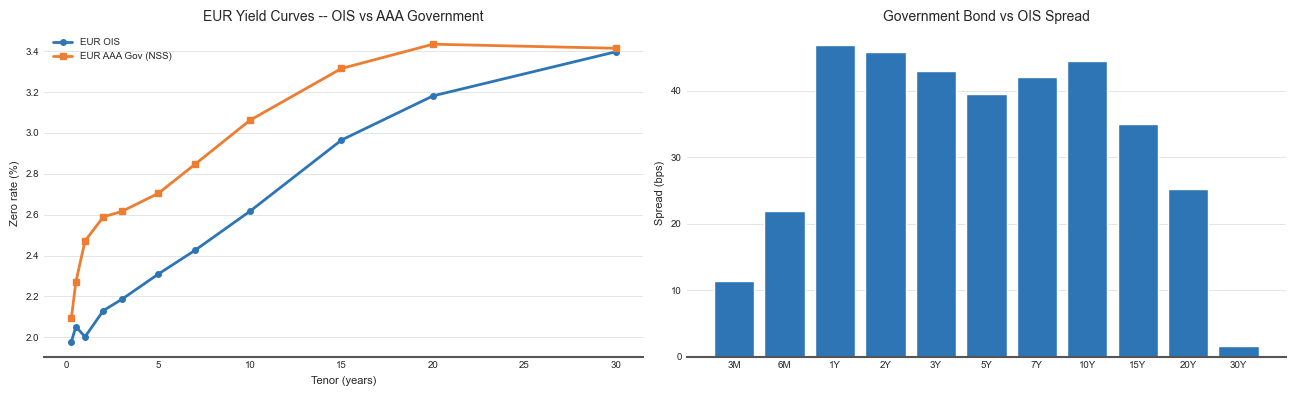

In [ ]:
# ── also load the NSS AAA government curve ────────────────────────────────────
# The NSS curve gives us EUR government bond yields across the curve.
# The spread between NSS and OIS (government minus OIS) reflects
# the scarcity premium -- government bonds trade rich to OIS because
# of LCR demand, repo specialness, and safe-haven flows.

nss_rates = {label: nss_curve.zero_rate(T) for label, T in key_tenors.items()}
gov_ois_spread = {label: nss_rates[label] - ois_rates[label] for label in key_tenors}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4))

tenors_list = list(key_tenors.values())
labels_list = list(key_tenors.keys())

ax0.plot(tenors_list, list(ois_rates.values()), color=C1, linewidth=2,
             marker='o', markersize=4, label='EUR OIS')
ax0.plot(tenors_list, list(nss_rates.values()), color=C2, linewidth=2,
             marker='s', markersize=4, label='EUR AAA Gov (NSS)')
ax0.set_xlabel('Tenor (years)')
ax0.set_ylabel('Zero rate (%)')
ax0.set_title('EUR Yield Curves -- OIS vs AAA Government')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

spread_vals = list(gov_ois_spread.values())
colors_spread = [C4 if v < 0 else C1 for v in spread_vals]
ax1.bar(labels_list, [v * 100 for v in spread_vals],
            color=colors_spread, edgecolor='white')
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_ylabel('Spread (bps)')
ax1.set_title('Government Bond vs OIS Spread')
ax1.tick_params(axis='x')
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()


## 2. EUR Government Bond Relative Value -- Z-Spread Analysis



In the code below we use hard coded data for EUR denominated gov bonds, and load it into QuantLib **bond** objects.  This is convenient to compute dv01, price and z-spread.

<small> 

| Ticker | Issuer | Country | Full name |
|--------|--------|---------|----------|
| Bund | Federal Republic of Germany | Germany | Bundesanleihe |
| OAT | French Republic | France | Obligation Assimilable du Trésor |
| BTP | Italian Republic | Italy | Buoni del Tesoro Poliennali |
| OLO | Kingdom of Belgium | Belgium | Obligations Linéaires / Lineaire Obligaties |

</small> 


In [3]:
# ── EUR government bond universe ──────────────────────────────────────────────
# We build a representative cross-section of EUR government bonds.
# Prices are set at approximate market levels as of the valuation date.
# In production these would come from a pricing service (Bloomberg, Refinitiv).

# hard coded inputs for demonstration -- in production these would come from a data source
gov_bonds = [
    # Germany (Bund) -- benchmark, tightest spreads
    {'name': 'Bund 2.5% 2027',   'isin': 'DE0001102572', 'country': 'DE', 'coupon': 2.50, 'issue': '2024-10-18', 'maturity': '2027-10-18', 'clean_price': 99.85},
    {'name': 'Bund 2.5% 2030',   'isin': 'DE0001102580', 'country': 'DE', 'coupon': 2.50, 'issue': '2023-08-15', 'maturity': '2030-08-15', 'clean_price': 98.60},
    {'name': 'Bund 2.6% 2034',   'isin': 'DE0001102598', 'country': 'DE', 'coupon': 2.60, 'issue': '2024-08-15', 'maturity': '2034-08-15', 'clean_price': 97.20},
    {'name': 'Bund 2.5% 2046',   'isin': 'DE0001102564', 'country': 'DE', 'coupon': 2.50, 'issue': '2024-08-15', 'maturity': '2046-08-15', 'clean_price': 90.10},
    # France (OAT) -- slight spread to Bund
    {'name': 'OAT 3.0% 2028',    'isin': 'FR0014002WS6', 'country': 'FR', 'coupon': 3.00, 'issue': '2022-04-25', 'maturity': '2028-05-25', 'clean_price': 100.80},
    {'name': 'OAT 3.0% 2032',    'isin': 'FR0014003S39', 'country': 'FR', 'coupon': 3.00, 'issue': '2022-10-25', 'maturity': '2032-10-25', 'clean_price': 99.10},
    {'name': 'OAT 3.5% 2035',    'isin': 'FR0014004L86', 'country': 'FR', 'coupon': 3.50, 'issue': '2023-01-15', 'maturity': '2035-04-25', 'clean_price': 101.50},
    # Italy (BTP) -- wider spread, peripheral
    {'name': 'BTP 4.0% 2028',    'isin': 'IT0005534992', 'country': 'IT', 'coupon': 4.00, 'issue': '2023-02-01', 'maturity': '2028-02-01', 'clean_price': 101.20},
    {'name': 'BTP 4.5% 2033',    'isin': 'IT0005518128', 'country': 'IT', 'coupon': 4.50, 'issue': '2022-09-01', 'maturity': '2033-06-01', 'clean_price': 103.80},
    {'name': 'BTP 4.75% 2044',   'isin': 'IT0005480360', 'country': 'IT', 'coupon': 4.75, 'issue': '2021-09-01', 'maturity': '2044-09-01', 'clean_price': 103.50},
    # Belgium (OLO)
    {'name': 'OLO 2.75% 2030',   'isin': 'BE0000356806', 'country': 'BE', 'coupon': 2.75, 'issue': '2023-03-06', 'maturity': '2030-06-22', 'clean_price': 99.40},
    {'name': 'OLO 3.3% 2034',    'isin': 'BE0000356897', 'country': 'BE', 'coupon': 3.30, 'issue': '2023-09-04', 'maturity': '2034-06-22', 'clean_price': 101.20},
]

gov_bonds_df = pd.DataFrame(gov_bonds)

# ── price each bond and compute z-spread ─────────────────────────────────────

# create QuantLib bond objects
results = []
for _, row in gov_bonds_df.iterrows():
    bond = Bond(
        isin          = row['isin'],
        face_value    = 100,
        coupon_rate   = row['coupon'],
        issue_date    = row['issue'],
        maturity_date = row['maturity'],
    )

    # price the bond using the OIS curve as discounting
    p        = bond.price(ois_curve)
    duration = p['duration']
    dv01     = bond.dv01(ois_curve)
    z_spread = bond.z_spread(row['clean_price'], ois_curve)
    ytm      = p['ytm']

    # collect results
    results.append({
        'name':      row['name'],
        'country':   row['country'],
        'maturity':  row['maturity'],
        'coupon':    row['coupon'],
        'clean_price': row['clean_price'],
        'ytm':       ytm,
        'duration':  duration,
        'dv01':      dv01,
        'z_spread_bps': z_spread * 100,
    })

rv_df = pd.DataFrame(results)

print("EUR Government Bond Universe -- Z-Spread Analysis")
rv_df[['name','country','ytm','duration','dv01','z_spread_bps']]

EUR Government Bond Universe -- Z-Spread Analysis


,name,country,ytm,duration,dv01,z_spread_bps
0,Bund 2.5% 2027,DE,2.112000,1.512400,0.020000,4787.310000
1,Bund 2.5% 2030,DE,2.305300,4.062000,0.040000,5337.980000
2,Bund 2.6% 2034,DE,2.539100,7.348000,0.080000,4409.020000
3,Bund 2.5% 2046,DE,3.190000,15.199000,0.140000,-244.990000
4,OAT 3.0% 2028,FR,2.157700,2.035500,0.020000,4556.600000
5,OAT 3.0% 2032,FR,2.419000,5.875400,0.060000,7340.360000
6,OAT 3.5% 2035,FR,2.562000,7.564400,0.090000,7454.970000
7,BTP 4.0% 2028,IT,2.095900,1.782000,0.020000,12432.690000
8,BTP 4.5% 2033,IT,2.441600,6.015300,0.070000,14468.240000
9,BTP 4.75% 2044,IT,3.053400,12.652400,0.160000,14314.520000


Relative value in government bonds is about identifying bonds that are
**cheap or rich** relative to the curve, after controlling for duration.

**Z-spread** is the parallel shift to the OIS discount curve that makes
the theoretical bond price equal to the observed market price:

$$P_{market} = \sum_{i=1}^{n} \frac{CF_i}{(1 + r_i^{OIS} + z)^{t_i}}$$

A bond with a positive z-spread is **cheap** relative to OIS -- it
offers more yield than the curve implies. A negative z-spread is **rich**.

------

Note: yield vs. z-spread

I waht comes below we use continuous compound rtes as OIS curve use that convention.

The yield is the single flat discount rate that makes the present value
of all cash flows equal to the market price:

$$P_{market} = \sum_{i=1}^{n} CF_i \cdot e^{-y \cdot t_i}$$

The z-spread is the single constant spread added to the OIS curve at
every tenor that achieves the same:

$$P_{market} = \sum_{i=1}^{n} \frac{CF_i}{e^{(r_i^{OIS} + z) \cdot t_i}}$$

**Why use z-spread over yield?**

**Yield ignores the shape of the curve**: it uses one flat rate to
discount all cash flows regardless of tenor. Two bonds with the same
yield but different maturities are not directly comparable because
they are being discounted against different parts of the curve.

**Z-spread respects the term structure**: the OIS rate at each tenor
provides the **risk-free anchor**, and $z$ is the pure excess compensation
the bond offers above that. Two bonds with the same z-spread offer the
same spread over the risk-free curve regardless of maturity, making
them directly comparable for relative value analysis.

-----

**Z-spread vs ASW (Asset Swap Spread):**
The asset swap spread (ASW) measures the spread of the bond yield over
the fixed rate on a matched-maturity swap. Z-spread is more rigorous
because it accounts for the full term structure, while ASW uses a
single par swap rate. 

**DV01-adjusted spread:**
When comparing two bonds of different durations, a spread comparison
is only valid if adjusted for DV01. A 5Y and a 10Y bond with the same
z-spread do not represent equal risk -- the 10Y has twice the rate
sensitivity. The DV01-adjusted position sizes the trade so that the
DV01 is equal on both legs.

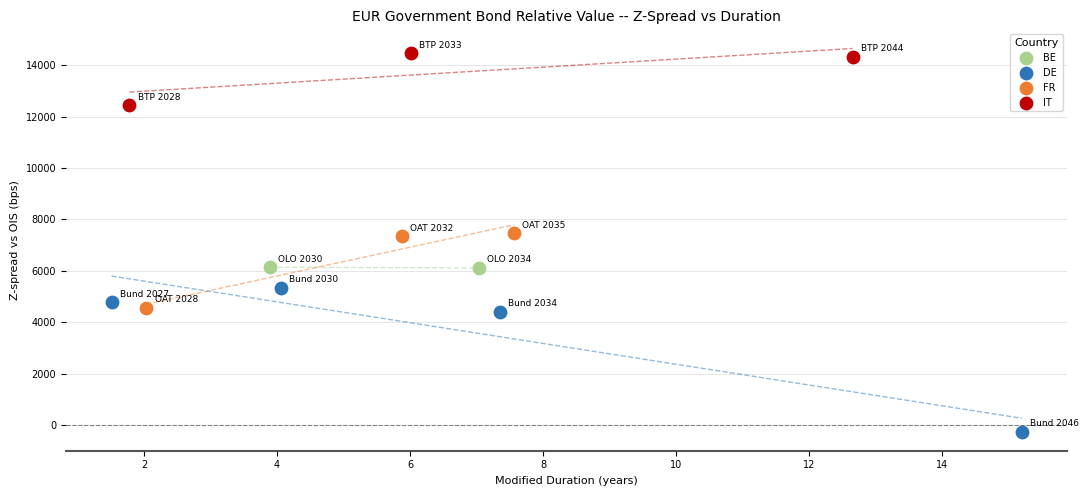

Bonds above dashed line: CHEAP within issuer -- buy candidates
Bonds below dashed line: RICH within issuer -- sell candidates


In [4]:
# ── z-spread by duration -- the RV chart ──────────────────────────────────────
# The most common RV visualisation in fixed income:
# plot z-spread vs duration for each bond.

# The fitted line represents fair value for each issuer.
# Bonds above the line are cheap (positive residual -- buy signal).
# Bonds below the line are rich (negative residual -- sell signal).
# Note: DV01 adjustment is applied at position sizing stage, not here.
# The chart identifies the signal -- the trade construction in section 3
# converts the signal into a DV01-neutral position.

country_colors = {'DE': C1, 'FR': C2, 'IT': C4, 'BE': C3}

fig, ax = plt.subplots(figsize=(11, 5))

for country, group in rv_df.groupby('country'):
    ax.scatter(group['duration'], group['z_spread_bps'],
               color=country_colors[country], s=80, zorder=5, label=country)
    for _, row in group.iterrows():
        ax.annotate(row['name'].split(' ')[0] + ' ' + row['maturity'][:4],
                    (row['duration'], row['z_spread_bps']),
                    textcoords='offset points', xytext=(6, 4), fontsize=6.5)

# fit a line per country to identify cheap/rich bonds within each issuer
for country, group in rv_df.groupby('country'):
    if len(group) >= 2:
        m, b, _, _, _ = stats.linregress(group['duration'], group['z_spread_bps'])
        x_range = np.linspace(group['duration'].min(), group['duration'].max(), 50)
        ax.plot(x_range, m * x_range + b, color=country_colors[country],
                linestyle='--', linewidth=1, alpha=0.5)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Modified Duration (years)')
ax.set_ylabel('Z-spread vs OIS (bps)')
ax.set_title('EUR Government Bond Relative Value -- Z-Spread vs Duration')
ax.legend(title='Country')
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

print("Bonds above dashed line: CHEAP within issuer -- buy candidates")
print("Bonds below dashed line: RICH within issuer -- sell candidates")

In [5]:
# ── residual z-spread -- the RV signal ───────────────────────────────────────
# For each country, compute the residual z-spread relative to the
# fitted duration-spread relationship.
# A positive residual = the bond is cheap to its own curve.
# A negative residual = the bond is rich to its own curve.

rv_df['z_residual_bps'] = np.nan

for country, group in rv_df.groupby('country'):
    if len(group) >= 2:
        m, b, _, _, _ = stats.linregress(group['duration'], group['z_spread_bps'])
        fitted = m * group['duration'] + b
        rv_df.loc[group.index, 'z_residual_bps'] = group['z_spread_bps'].values - fitted.values

print("Z-Spread Residuals -- RV Signal by Bond")
print(f"{'Bond':<25} {'Country':>8} {'Z-spread':>10} {'Residual':>10} {'Signal':>10}")
print("-" * 68)
for _, row in rv_df.sort_values('z_residual_bps', ascending=False).iterrows():
    signal = 'BUY' if row['z_residual_bps'] > 2 else ('SELL' if row['z_residual_bps'] < -2 else 'NEUTRAL')
    print(f"{row['name']:<25} {row['country']:>8} {row['z_spread_bps']:>8.1f}bps {row['z_residual_bps']:>+8.1f}bps {signal:>10}")

Z-Spread Residuals -- RV Signal by Bond
Bond                       Country   Z-spread   Residual     Signal
--------------------------------------------------------------------
Bund 2.6% 2034                  DE   4409.0bps   +965.0bps        BUY
BTP 4.5% 2033                   IT  14468.2bps   +854.5bps        BUY
Bund 2.5% 2030                  DE   5338.0bps   +566.4bps        BUY
OAT 3.0% 2032                   FR   7340.4bps   +489.2bps        BUY
OLO 2.75% 2030                  BE   6145.2bps     +0.0bps    NEUTRAL
OLO 3.3% 2034                   BE   6119.0bps     +0.0bps    NEUTRAL
OAT 3.0% 2028                   FR   4556.6bps   -149.4bps       SELL
BTP 4.75% 2044                  IT  14314.5bps   -332.8bps       SELL
OAT 3.5% 2035                   FR   7455.0bps   -339.7bps       SELL
Bund 2.5% 2046                  DE   -245.0bps   -517.0bps       SELL
BTP 4.0% 2028                   IT  12432.7bps   -521.8bps       SELL
Bund 2.5% 2027                  DE   4787.3bps  -1014

## 3. Curve Trades -- Slope and Curvature

Curve trades express a view on the shape of the yield curve rather
than the direction of rates. They are duration-neutral -- the DV01 of
the long leg equals the DV01 of the short leg.

**Flattener:** short the long end (or long the short end).
Profits when the curve flattens -- long rates fall relative to short rates.
Typical trade in late cycle when central bank is done hiking.

**Steepener:** long the long end (or short the short end).
Profits when the curve steepens -- long rates rise relative to short rates.
Typical trade when central bank starts cutting -- short rates fall faster.

**Butterfly:** a three-legged trade. Long the belly (5Y), short the wings
(2Y and 10Y). Profits when the belly cheapens relative to the wings.
The DV01 weighting must be carefully set so the trade is also
duration-neutral and convexity-neutral.

**DV01-neutral weighting:**
For a two-leg trade, the notional ratio is:

$$\frac{N_{short}}{N_{long}} = \frac{DV01_{long}}{DV01_{short}}$$

This ensures that a parallel shift in rates generates zero P&L --
the trade only profits from a change in the spread between the two legs.

In [6]:
# ── curve slope analysis -- 2s10s and 5s30s ───────────────────────────────────
# We use the OIS curve to measure the current slope and
# construct a hypothetical curve trade.

r_2y  = ois_curve.zero_rate(2.0)
r_5y  = ois_curve.zero_rate(5.0)
r_10y = ois_curve.zero_rate(10.0)
r_30y = ois_curve.zero_rate(30.0)

slope_2s10s = r_10y - r_2y
slope_5s30s = r_30y - r_5y
butterfly   = 2 * r_5y - r_2y - r_10y

print(f"EUR OIS Curve Shape")
print(f"  2Y rate:      {r_2y:.3f}%")
print(f"  5Y rate:      {r_5y:.3f}%")
print(f"  10Y rate:     {r_10y:.3f}%")
print(f"  30Y rate:     {r_30y:.3f}%")
print(f"\n  2s10s slope:  {slope_2s10s*100:+.1f}bps")
print(f"  5s30s slope:  {slope_5s30s*100:+.1f}bps")
print(f"  Butterfly:    {butterfly*100:+.1f}bps (2s5s10s)")



EUR OIS Curve Shape
  2Y rate:      2.131%
  5Y rate:      2.310%
  10Y rate:     2.617%
  30Y rate:     3.398%

  2s10s slope:  +48.6bps
  5s30s slope:  +108.8bps
  Butterfly:    -12.9bps (2s5s10s)


In [7]:
# ── DV01-neutral 2s10s flattener ─────────────────────────────────────────────
# Trade: short 10Y Bund (sell duration), long 2Y Bund (buy short end)
# DV01-neutral: size the short 10Y position so DV01 matches the long 2Y

bund_2y  = rv_df[rv_df['name'] == 'Bund 2.5% 2027'].iloc[0]
bund_10y = rv_df[rv_df['name'] == 'Bund 2.6% 2034'].iloc[0]

notional_10y = 10_000_000   # EUR 10M in the 10Y leg
# DV01-neutral ratio: N_2y / N_10y = DV01_10y / DV01_2y
dv01_ratio   = abs(bund_10y['dv01']) / abs(bund_2y['dv01'])
notional_2y  = notional_10y * dv01_ratio

# carry must be notional-weighted -- the two legs have different notionals
# a simple yield difference is only valid when both legs have equal notional
carry_2y  = bund_2y['ytm']  / 100 * notional_2y    # annual income from long 2Y
carry_10y = bund_10y['ytm'] / 100 * notional_10y   # annual income paid on short 10Y
net_carry = carry_2y - carry_10y                    # net annual carry in EUR

print(f"2s10s Bund Flattener -- DV01-Neutral Construction")
print(f"  Short {notional_10y/1e6:.0f}M {bund_10y['name']} (sell duration)")
print(f"  Long  {notional_2y/1e6:.1f}M {bund_2y['name']} (buy short end)")
print(f"  DV01 ratio: {dv01_ratio:.2f}x")
print(f"  Net DV01:   ~0 (duration neutral)")
print(f"\n  Carry (notional-weighted):")
print(f"    Long 2Y income:    EUR {carry_2y:>10,.0f}")
print(f"    Short 10Y income:  EUR {carry_10y:>10,.0f}")
print(f"    Net carry:         EUR {net_carry:>10,.0f} per year")
print(f"    Net carry in bps:  {net_carry / notional_10y * 10000:+.1f}bps (on 10Y notional)")
if net_carry > 0:
    print(f"    Positive carry -- flattener earns carry")
else:
    print(f"    Negative carry -- flattener costs carry")

2s10s Bund Flattener -- DV01-Neutral Construction
  Short 10M Bund 2.6% 2034 (sell duration)
  Long  40.0M Bund 2.5% 2027 (buy short end)
  DV01 ratio: 4.00x
  Net DV01:   ~0 (duration neutral)

  Carry (notional-weighted):
    Long 2Y income:    EUR    844,800
    Short 10Y income:  EUR    253,910
    Net carry:         EUR    590,890 per year
    Net carry in bps:  +590.9bps (on 10Y notional)
    Positive carry -- flattener earns carry


In [8]:
# ── butterfly trade construction ──────────────────────────────────────────────
# Butterfly: long belly (5Y), short wings (2Y and 10Y)
# Three conditions:
#   1. DV01 neutral: DV01_2y * N_2y + DV01_10y * N_10y + DV01_5y * N_5y = 0
#   2. Dollar-neutral: usually set N_2y = N_10y (equal notional on wings)
#   3. This gives us N_5y from condition 1

bund_5y = rv_df[rv_df['name'] == 'Bund 2.5% 2030'].iloc[0]

notional_wing = 5_000_000   # EUR 5M on each wing
# DV01 neutral: N_5y = -(N_2y * DV01_2y + N_10y * DV01_10y) / DV01_5y
# Short wings: negative notional on 2Y and 10Y
dv01_wings  = -notional_wing * bund_2y['dv01'] + (-notional_wing) * bund_10y['dv01']
notional_5y = -dv01_wings / bund_5y['dv01']

print(f"2s5s10s Bund Butterfly -- Long Belly")
print(f"  Short {notional_wing/1e6:.0f}M {bund_2y['name']}  (short 2Y wing)")
print(f"  Long  {notional_5y/1e6:.1f}M {bund_5y['name']}  (long 5Y belly)")
print(f"  Short {notional_wing/1e6:.0f}M {bund_10y['name']} (short 10Y wing)")
print(f"\n  Net DV01 check:")
net_dv01 = (-notional_wing * bund_2y['dv01'] +
             notional_5y  * bund_5y['dv01']  +
            -notional_wing * bund_10y['dv01'])
print(f"    {net_dv01:.2f} (should be ~0)")
print(f"\n  Butterfly spread: {butterfly*100:+.1f}bps")
print(f"  Trade profits if belly cheapens (butterfly spread increases)")

2s5s10s Bund Butterfly -- Long Belly
  Short 5M Bund 2.5% 2027  (short 2Y wing)
  Long  12.5M Bund 2.5% 2030  (long 5Y belly)
  Short 5M Bund 2.6% 2034 (short 10Y wing)

  Net DV01 check:
    0.00 (should be ~0)

  Butterfly spread: -12.9bps
  Trade profits if belly cheapens (butterfly spread increases)


## 4. Cross-Country Spreads -- Bund vs OAT vs BTP

Cross-country spreads measure the credit and political risk premium
of peripheral and semi-core EUR sovereign bonds relative to Germany
(Bund), the EUR risk-free benchmark.

**Bund spread** = yield of foreign country bond minus yield of same-maturity Bund.

The spread reflects:
- **Credit risk** -- probability of sovereign default or restructuring
- **Liquidity risk** -- Bunds are the most liquid EUR bonds
- **Political risk** -- fiscal policy uncertainty, euro exit risk
- **ECB purchase support** -- PEPP and TPI (Transmission Protection Instrument) cap spreads

**Matched-maturity spread** -- to compute a clean spread, we compare
bonds at the same maturity on the yield curve rather than using bonds
with different residual maturities. We use the NSS curve to read off
par yields at standard tenors for each country.

In practice, cross-country spread trades are implemented via:
- **Cash bonds:** long BTP, short Bund (repo-funded, carry cost applies)
- **Futures:** long BTP future, short Bund future (cleaner, no repo)
- **ASW:** asset swap spread as a funding-cost-neutral measure

In [9]:
# ── cross-country spread analysis ─────────────────────────────────────────────
# For each bond, compute the spread to the Bund curve at matched maturity.
# We use the z-spread as a clean duration-adjusted measure.

# Bund z-spreads as the benchmark (should be near zero -- Bund IS the benchmark)
bund_bonds    = rv_df[rv_df['country'] == 'DE'].copy()
oat_bonds     = rv_df[rv_df['country'] == 'FR'].copy()
btp_bonds     = rv_df[rv_df['country'] == 'IT'].copy()
olo_bonds     = rv_df[rv_df['country'] == 'BE'].copy()

# cross-country spread = z-spread of foreign bond - average Bund z-spread
# (Bund z-spread is the reference -- Germany IS the risk-free benchmark in EUR)
bund_avg_z = bund_bonds['z_spread_bps'].mean()

print(f"Cross-Country Spread Analysis -- vs Bund")
print(f"Bund average z-spread (benchmark): {bund_avg_z:.1f}bps")
print(f"\n{'Bond':<25} {'Country':>8} {'Duration':>10} {'Z-spread':>10} {'vs Bund':>10}")
print("-" * 68)
for _, row in rv_df.sort_values(['country','duration']).iterrows():
    vs_bund = row['z_spread_bps'] - bund_avg_z
    print(f"{row['name']:<25} {row['country']:>8} {row['duration']:>10.2f}y {row['z_spread_bps']:>8.1f}bps {vs_bund:>+8.1f}bps")

# ── spread by country at matched tenors ───────────────────────────────────────
# Use NSS curve to compute spreads at standard tenors
# We approximate peripheral sovereign spreads using z-spread data

country_avg_spread = rv_df.groupby('country')['z_spread_bps'].mean() - bund_avg_z
print(f"\nAverage cross-country spread by issuer:")
for country, spread in country_avg_spread.items():
    print(f"  {country}: {spread:+.1f}bps vs Bund")

Cross-Country Spread Analysis -- vs Bund
Bund average z-spread (benchmark): 3572.3bps

Bond                       Country   Duration   Z-spread    vs Bund
--------------------------------------------------------------------
OLO 2.75% 2030                  BE       3.90y   6145.2bps  +2572.9bps
OLO 3.3% 2034                   BE       7.03y   6119.0bps  +2546.7bps
Bund 2.5% 2027                  DE       1.51y   4787.3bps  +1215.0bps
Bund 2.5% 2030                  DE       4.06y   5338.0bps  +1765.7bps
Bund 2.6% 2034                  DE       7.35y   4409.0bps   +836.7bps
Bund 2.5% 2046                  DE      15.20y   -245.0bps  -3817.3bps
OAT 3.0% 2028                   FR       2.04y   4556.6bps   +984.3bps
OAT 3.0% 2032                   FR       5.88y   7340.4bps  +3768.0bps
OAT 3.5% 2035                   FR       7.56y   7455.0bps  +3882.6bps
BTP 4.0% 2028                   IT       1.78y  12432.7bps  +8860.4bps
BTP 4.5% 2033                   IT       6.02y  14468.2bps +10895.

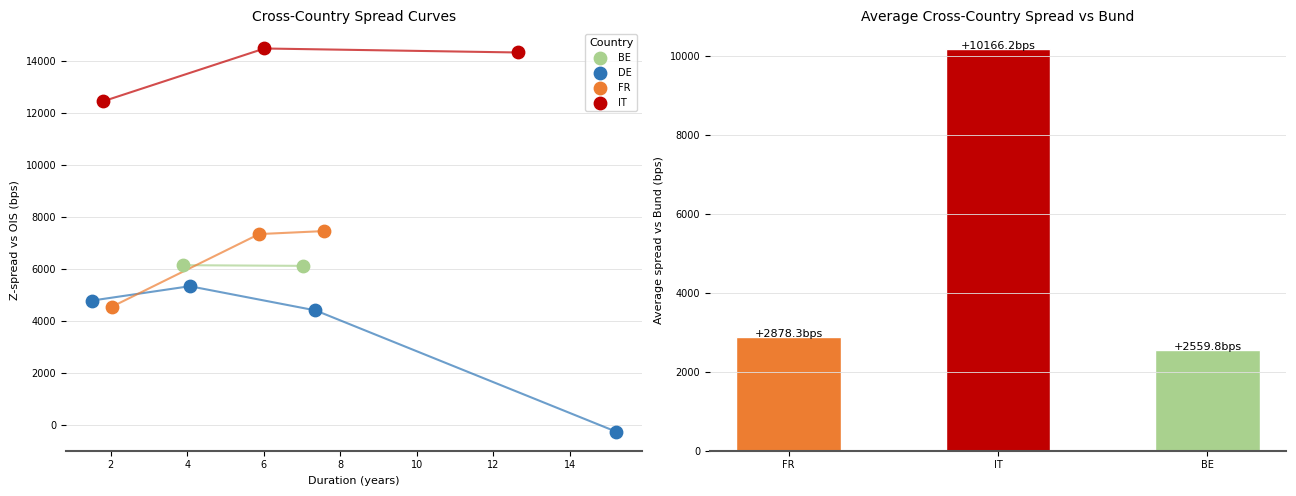

In [ ]:
# ── cross-country spread visualisation ───────────────────────────────────────
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

# left: z-spread by country and duration
for country, group in rv_df.groupby('country'):
    ax0.scatter(group['duration'], group['z_spread_bps'],
                    color=country_colors[country], s=80, label=country, zorder=5)
    if len(group) >= 2:
        ax0.plot(group['duration'].sort_values(),
                     group.sort_values('duration')['z_spread_bps'],
                     color=country_colors[country], linewidth=1.5, alpha=0.7)

ax0.set_xlabel('Duration (years)')
ax0.set_ylabel('Z-spread vs OIS (bps)')
ax0.set_title('Cross-Country Spread Curves')
ax0.legend(title='Country')
ax0.spines['bottom'].set_color('#555555')

# right: spread histogram by country
countries = ['FR', 'IT', 'BE']
colors_bar = [C2, C4, C3]
x = np.arange(len(countries))
avg_spreads = [rv_df[rv_df['country']==c]['z_spread_bps'].mean() - bund_avg_z for c in countries]
bars = ax1.bar(countries, avg_spreads, color=colors_bar, edgecolor='white', width=0.5)
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_ylabel('Average spread vs Bund (bps)')
ax1.set_title('Average Cross-Country Spread vs Bund')
for bar, val in zip(bars, avg_spreads):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:+.1f}bps', ha='center', fontsize=8)
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 5. Pair Trading -- Statistical Framework

Pair trading in fixed income exploits the mean-reverting behaviour of
spreads between closely related bonds. The statistical framework requires:

**Step 1 -- Cointegration test:**
Two bonds are cointegrated if their spread is stationary (mean-reverting)
even though each bond yield individually is non-stationary (I(1) process).
Use the Engle-Granger test: regress bond A yield on bond B yield, test
if the residual is stationary via Augmented Dickey-Fuller (ADF).

**Step 2 -- Hedge ratio:**
The OLS coefficient from the regression gives the hedge ratio $\beta$:

$$y_A = \alpha + \beta \cdot y_B + \epsilon_t$$

The spread $\epsilon_t = y_A - \alpha - \beta \cdot y_B$ should be
stationary and mean-reverting.

**Step 3 -- Z-score signal:**
Normalise the spread by its rolling mean and standard deviation:

$$z_t = \frac{\epsilon_t - \mu_{\epsilon}}{\sigma_{\epsilon}}$$

Entry signal: $|z_t| > 2$ (spread more than 2 sigma from mean).
Exit signal: $|z_t| < 0.5$ (spread returns near mean).

**Step 4 -- DV01-neutral position sizing:**
Even with a statistical hedge ratio, the position must be DV01-neutral
to avoid directional rate exposure. Adjust the notional of each leg
so that $DV01_{A} \times N_A = DV01_{B} \times N_B$.

In [11]:
# ── simulate historical yield series for pair trading ─────────────────────────
# In production, historical yields would come from Bloomberg or Refinitiv.
# Here we simulate realistic yield dynamics using a mean-reverting process
# calibrated to current levels -- this demonstrates the statistical methodology.

np.random.seed(42)
n_days = 252   # one year of daily data

# Simulate correlated yield series for OAT 10Y and BTP 10Y
# Both mean-revert to their respective fair values, with correlation

# Parameters calibrated to approximate EUR gov bond dynamics
mu_oat   = rv_df[rv_df['name'] == 'OAT 3.0% 2032']['ytm'].values[0]
mu_btp   = rv_df[rv_df['name'] == 'BTP 4.5% 2033']['ytm'].values[0]
kappa    = 0.05    # mean reversion speed
sigma_oa = 0.0040  # daily vol OAT
sigma_bt = 0.0055  # daily vol BTP (higher -- more volatile peripheral)
corr     = 0.85    # correlation between OAT and BTP

# Cholesky decomposition for correlated shocks
cov_matrix = np.array([[sigma_oa**2, corr*sigma_oa*sigma_bt],
                        [corr*sigma_oa*sigma_bt, sigma_bt**2]])
L = np.linalg.cholesky(cov_matrix)

yields_oat = [mu_oat]
yields_btp = [mu_btp]

for _ in range(n_days - 1):
    z = np.random.standard_normal(2)
    shocks = L @ z
    dy_oat = kappa * (mu_oat - yields_oat[-1]) + shocks[0]
    dy_btp = kappa * (mu_btp - yields_btp[-1]) + shocks[1]
    yields_oat.append(yields_oat[-1] + dy_oat)
    yields_btp.append(yields_btp[-1] + dy_btp)

yields_oat = np.array(yields_oat)
yields_btp = np.array(yields_btp)
btp_oat_spread = yields_btp - yields_oat
days = np.arange(n_days)

print(f"Simulated Yield Series -- OAT vs BTP 10Y (252 days)")
print(f"OAT range:   {yields_oat.min()*100:.2f}% -- {yields_oat.max()*100:.2f}%")
print(f"BTP range:   {yields_btp.min()*100:.2f}% -- {yields_btp.max()*100:.2f}%")
print(f"Spread range:{btp_oat_spread.min()*100:.1f}bps -- {btp_oat_spread.max()*100:.1f}bps")

Simulated Yield Series -- OAT vs BTP 10Y (252 days)
OAT range:   240.13% -- 245.19%
BTP range:   241.25% -- 247.62%
Spread range:0.6bps -- 4.6bps


In [12]:
# ── cointegration and hedge ratio ─────────────────────────────────────────────
# Step 1: OLS regression of BTP yield on OAT yield
# y_BTP = alpha + beta * y_OAT + epsilon

from scipy import stats as sp_stats

beta, alpha, r_value, p_value, std_err = sp_stats.linregress(yields_oat, yields_btp)
spread_residual = yields_btp - (alpha + beta * yields_oat)

# Step 2: ADF test on residuals (simplified -- check autocorrelation of differences)
# In production use statsmodels adfuller
spread_diff   = np.diff(spread_residual)
acf_lag1      = np.corrcoef(spread_residual[:-1], spread_residual[1:])[0,1]

print(f"Cointegration Analysis -- OAT vs BTP 10Y")
print(f"  Hedge ratio (beta):    {beta:.4f}")
print(f"  Intercept (alpha):     {alpha*100:.3f}%")
print(f"  R-squared:             {r_value**2:.4f}")
print(f"  Residual autocorr(1):  {acf_lag1:.4f}")
print(f"  (negative autocorr suggests mean reversion)")

# Step 3: z-score signal
roll_window  = 60   # 60-day rolling window for mean and std
roll_mean    = pd.Series(spread_residual).rolling(roll_window).mean().values
roll_std     = pd.Series(spread_residual).rolling(roll_window).std().values
z_score      = (spread_residual - roll_mean) / roll_std

# Entry/exit thresholds
entry_z  = 2.0
exit_z   = 0.5

# Signal: +1 = BTP cheap vs OAT (buy BTP, sell OAT)
#         -1 = BTP rich vs OAT (sell BTP, buy OAT)
#          0 = no position
signal = np.zeros(n_days)
position = 0
for i in range(roll_window, n_days):
    if position == 0:
        if z_score[i] > entry_z:    # BTP cheap
            position = 1
        elif z_score[i] < -entry_z:  # BTP rich
            position = -1
    else:
        if abs(z_score[i]) < exit_z:  # spread normalised
            position = 0
    signal[i] = position

n_trades = np.sum(np.abs(np.diff(signal)) > 0)
print(f"\nPair Trading Signal")
print(f"  Entry threshold:  ±{entry_z} sigma")
print(f"  Exit threshold:   ±{exit_z} sigma")
print(f"  Number of trades: {n_trades}")
print(f"  Long BTP days:    {(signal == 1).sum()}")
print(f"  Short BTP days:   {(signal == -1).sum()}")
print(f"  Flat days:        {(signal == 0).sum()}")

Cointegration Analysis -- OAT vs BTP 10Y
  Hedge ratio (beta):    1.1155
  Intercept (alpha):     -25.549%
  R-squared:             0.7015
  Residual autocorr(1):  0.9305
  (negative autocorr suggests mean reversion)

Pair Trading Signal
  Entry threshold:  ±2.0 sigma
  Exit threshold:   ±0.5 sigma
  Number of trades: 10
  Long BTP days:    43
  Short BTP days:   38
  Flat days:        171


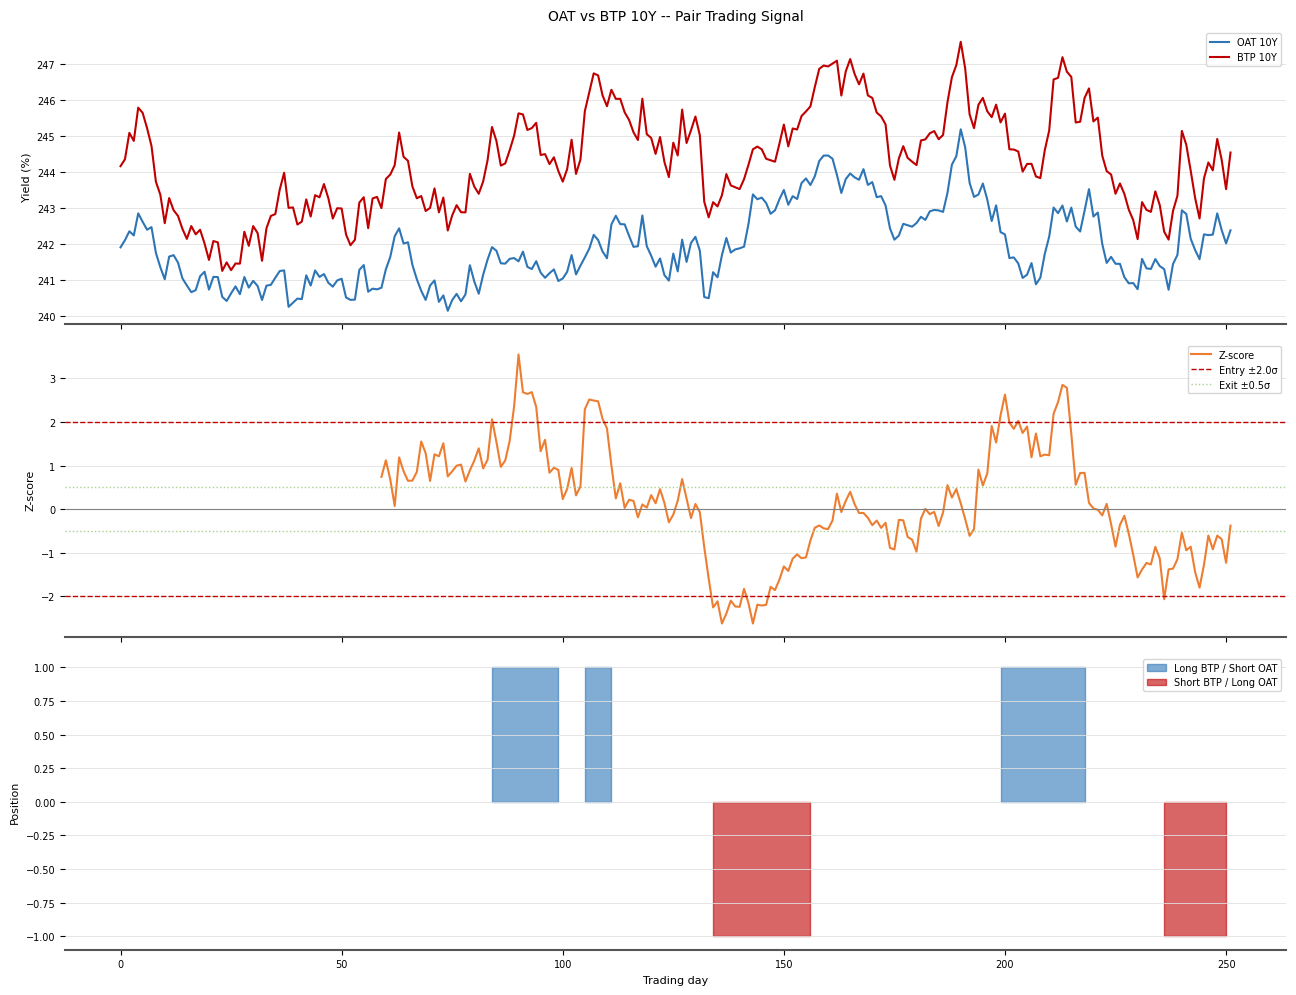

In [ ]:
# ── pair trading signal visualisation ────────────────────────────────────────
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# top: yield series
ax0.plot(days, yields_oat * 100, color=C1, linewidth=1.5, label='OAT 10Y')
ax0.plot(days, yields_btp * 100, color=C4, linewidth=1.5, label='BTP 10Y')
ax0.set_ylabel('Yield (%)')
ax0.set_title('OAT vs BTP 10Y -- Pair Trading Signal')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

# middle: z-score with signals
ax1.plot(days, z_score, color=C2, linewidth=1.5, label='Z-score')
ax1.axhline(entry_z,  color=C4, linestyle='--', linewidth=1, label=f'Entry ±{entry_z}σ')
ax1.axhline(-entry_z, color=C4, linestyle='--', linewidth=1)
ax1.axhline(exit_z,   color=C3, linestyle=':', linewidth=1, label=f'Exit ±{exit_z}σ')
ax1.axhline(-exit_z,  color=C3, linestyle=':', linewidth=1)
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_ylabel('Z-score')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

# bottom: position
ax2.fill_between(days, signal, 0,
                     where=signal > 0, color=C1, alpha=0.6, label='Long BTP / Short OAT')
ax2.fill_between(days, signal, 0,
                     where=signal < 0, color=C4, alpha=0.6, label='Short BTP / Long OAT')
ax2.set_ylabel('Position')
ax2.set_xlabel('Trading day')
ax2.legend()
ax2.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

Pair Trade P&L Summary -- OAT vs BTP (simulated)
  Notional BTP:    EUR 10M
  Notional OAT:    EUR 11.7M (DV01 neutral)
  Total P&L:       EUR 11,772
  Sharpe ratio:    0.58
  Max drawdown:    EUR -10,797
  Win rate:        17.9%


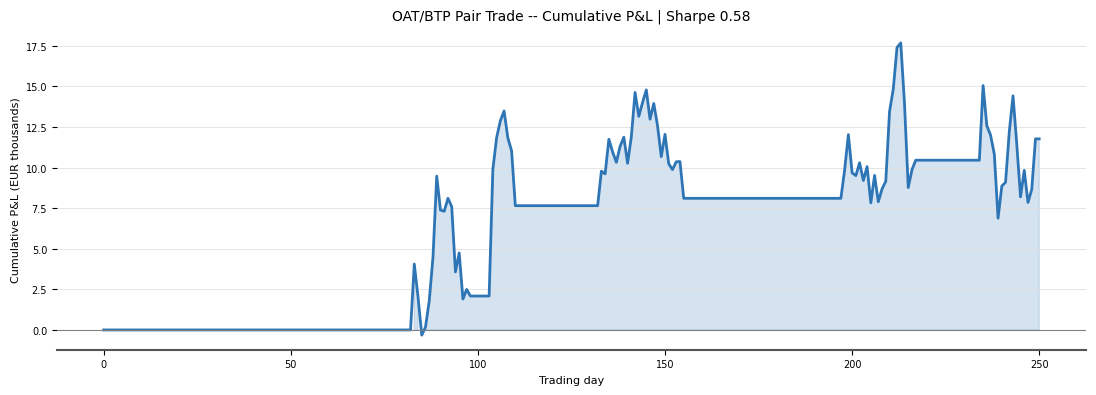

In [14]:
# ── P&L simulation -- DV01-neutral pair trade ─────────────────────────────────
# P&L of the pair trade is driven by the change in spread.
# Long BTP / short OAT profits when BTP cheapens vs OAT (spread widens).
# DV01-neutral means parallel rate moves generate no P&L.

# Notional sizing: EUR 10M in BTP, DV01-neutral in OAT
notional_btp = 10_000_000
dv01_btp     = rv_df[rv_df['name'] == 'BTP 4.5% 2033']['dv01'].values[0]
dv01_oat     = rv_df[rv_df['name'] == 'OAT 3.0% 2032']['dv01'].values[0]
notional_oat = notional_btp * abs(dv01_btp) / abs(dv01_oat)

# Daily P&L: position × (spread change) × DV01 × notional / 0.0001
# Spread change in % -- DV01 is per 1bp
spread_daily_chg = np.diff(btp_oat_spread)  # in % -- convert to bps
daily_pnl = signal[1:] * spread_daily_chg * 100 * abs(dv01_btp) * notional_btp / 100
cum_pnl   = np.cumsum(daily_pnl)

sharpe = (np.mean(daily_pnl) / np.std(daily_pnl)) * np.sqrt(252) if np.std(daily_pnl) > 0 else 0
max_dd  = np.min(cum_pnl - np.maximum.accumulate(cum_pnl))

print(f"Pair Trade P&L Summary -- OAT vs BTP (simulated)")
print(f"  Notional BTP:    EUR {notional_btp/1e6:.0f}M")
print(f"  Notional OAT:    EUR {notional_oat/1e6:.1f}M (DV01 neutral)")
print(f"  Total P&L:       EUR {cum_pnl[-1]:,.0f}")
print(f"  Sharpe ratio:    {sharpe:.2f}")
print(f"  Max drawdown:    EUR {max_dd:,.0f}")
print(f"  Win rate:        {(daily_pnl > 0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(len(cum_pnl)), cum_pnl / 1000, color=C1, linewidth=2)
ax.fill_between(range(len(cum_pnl)), cum_pnl / 1000, 0,
                where=cum_pnl > 0, color=C1, alpha=0.2)
ax.fill_between(range(len(cum_pnl)), cum_pnl / 1000, 0,
                where=cum_pnl < 0, color=C4, alpha=0.2)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Trading day')
ax.set_ylabel('Cumulative P&L (EUR thousands)')
ax.set_title(f'OAT/BTP Pair Trade -- Cumulative P&L | Sharpe {sharpe:.2f}')
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 6. EUR IG Credit -- Adding the Credit Dimension

Investment grade corporate bonds add a credit spread on top of the
government curve. Relative value in IG credit operates on two levels:

**Level 1 -- Sector RV:** compare z-spreads across sectors (financials,
industrials, utilities) at matched duration. A sector trading wide
to its historical average may be a buy.

**Level 2 -- Single name RV:** within a sector, compare bonds of the
same issuer at different maturities (curve steepness) and bonds of
different issuers at the same maturity (cross-issuer spread).

**OAS -- Option-Adjusted Spread:**
For callable corporate bonds, the z-spread overstates the credit
compensation because part of the spread compensates for the embedded
call option. OAS removes the option value:

$$OAS = Z\text{-}spread - OptionValue$$

For non-callable bonds (most EUR IG), OAS = z-spread.

**Credit-rates relative value:**
Credit spreads and rates tend to be negatively correlated -- when rates
rise (growth fears), credit spreads often tighten (growth is good for
corporates). When rates fall (recession), credit spreads widen.
Understanding this correlation is critical for hedging a credit portfolio.

In [15]:
# ── EUR IG corporate bond universe ────────────────────────────────────────────
ig_bonds = [
    # Financials
    {'name': 'BNP 3.25% 2029',    'isin': 'FR001400F7X2', 'sector': 'Financials',   'coupon': 3.25, 'issue': '2024-01-15', 'maturity': '2029-01-15', 'clean_price': 100.20, 'rating': 'A'},
    {'name': 'Deutsche Bk 4% 2030','isin': 'DE000DB7XJU4','sector': 'Financials',   'coupon': 4.00, 'issue': '2023-03-15', 'maturity': '2030-03-15', 'clean_price': 101.80, 'rating': 'BBB'},
    {'name': 'ING 3.5% 2028',      'isin': 'XS2584120974', 'sector': 'Financials',  'coupon': 3.50, 'issue': '2023-04-10', 'maturity': '2028-04-10', 'clean_price': 100.90, 'rating': 'A'},
    # Industrials
    {'name': 'Volkswagen 3.25% 2028','isin':'XS2517200878','sector':'Industrials',  'coupon': 3.25, 'issue': '2023-01-18', 'maturity': '2028-01-18', 'clean_price':  99.80, 'rating': 'BBB'},
    {'name': 'Siemens 2.875% 2029', 'isin': 'DE000A3H2WJ3','sector': 'Industrials', 'coupon': 2.875,'issue': '2022-08-15', 'maturity': '2029-08-15', 'clean_price':  98.50, 'rating': 'A'},
    {'name': 'BASF 3.0% 2030',      'isin': 'XS2540671234','sector': 'Industrials', 'coupon': 3.00, 'issue': '2023-02-15', 'maturity': '2030-02-15', 'clean_price':  98.20, 'rating': 'A'},
    # Utilities
    {'name': 'Enel 3.5% 2029',      'isin': 'XS2551234567','sector': 'Utilities',   'coupon': 3.50, 'issue': '2023-03-20', 'maturity': '2029-03-20', 'clean_price': 100.40, 'rating': 'BBB'},
    {'name': 'Engie 2.75% 2028',    'isin': 'XS2478901234','sector': 'Utilities',   'coupon': 2.75, 'issue': '2022-09-15', 'maturity': '2028-09-15', 'clean_price':  98.80, 'rating': 'A'},
    {'name': 'Iberdrola 3.0% 2031', 'isin': 'XS2612345678','sector': 'Utilities',   'coupon': 3.00, 'issue': '2023-06-15', 'maturity': '2031-06-15', 'clean_price':  98.10, 'rating': 'BBB'},
]

ig_results = []
for row in ig_bonds:
    bond = Bond(
        isin          = row['isin'],
        face_value    = 100,
        coupon_rate   = row['coupon'],
        issue_date    = row['issue'],
        maturity_date = row['maturity'],
    )
    p        = bond.price(ois_curve)
    z_spread = bond.z_spread(row['clean_price'], ois_curve)
    ig_results.append({
        'name':         row['name'],
        'sector':       row['sector'],
        'rating':       row['rating'],
        'duration':     p['duration'],
        'dv01':         bond.dv01(ois_curve),
        'ytm':          p['ytm'],
        'z_spread_bps': z_spread * 100,
    })

ig_df = pd.DataFrame(ig_results)

print("EUR IG Corporate Bond Universe -- Z-Spread Analysis")
print(ig_df[['name','sector','rating','duration','ytm','z_spread_bps']].to_string(index=False))

EUR IG Corporate Bond Universe -- Z-Spread Analysis
                 name      sector rating  duration      ytm  z_spread_bps
       BNP 3.25% 2029  Financials      A  2.657400 2.213800   9506.340000
  Deutsche Bk 4% 2030  Financials    BBB  3.671700 2.280500  12184.850000
        ING 3.5% 2028  Financials      A  1.901000 2.198000   8235.290000
Volkswagen 3.25% 2028 Industrials    BBB  1.750000 2.142000  12122.680000
  Siemens 2.875% 2029 Industrials      A  3.159000 2.246100  10939.350000
       BASF 3.0% 2030 Industrials      A  3.644000 2.273000  12228.530000
       Enel 3.5% 2029   Utilities    BBB  2.822800 2.215200  11369.580000
     Engie 2.75% 2028   Utilities      A  2.343500 2.199200  10495.830000
  Iberdrola 3.0% 2031   Utilities    BBB  4.700200 2.354900  10418.070000


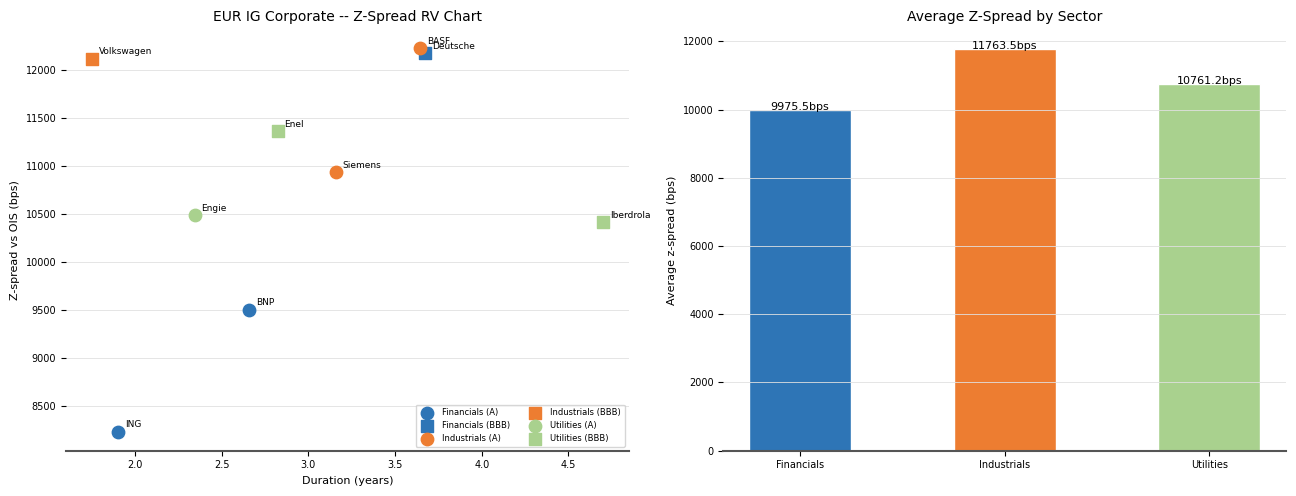

In [ ]:
# ── sector RV -- z-spread vs duration by sector ───────────────────────────────
sector_colors = {'Financials': C1, 'Industrials': C2, 'Utilities': C3}
rating_markers = {'A': 'o', 'BBB': 's'}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

for sector, group in ig_df.groupby('sector'):
    for rating, subgroup in group.groupby('rating'):
        ax0.scatter(subgroup['duration'], subgroup['z_spread_bps'],
                        color=sector_colors[sector],
                        marker=rating_markers.get(rating, 'o'),
                        s=80, zorder=5,
                        label=f'{sector} ({rating})')
        for _, row in subgroup.iterrows():
            ax0.annotate(row['name'].split(' ')[0],
                             (row['duration'], row['z_spread_bps']),
                             textcoords='offset points', xytext=(5, 3), fontsize=6.5)

ax0.set_xlabel('Duration (years)')
ax0.set_ylabel('Z-spread vs OIS (bps)')
ax0.set_title('EUR IG Corporate -- Z-Spread RV Chart')
ax0.legend(fontsize=6, ncol=2)
ax0.spines['bottom'].set_color('#555555')

# right: average z-spread by sector
sector_avg = ig_df.groupby('sector')['z_spread_bps'].mean()
bars = ax1.bar(sector_avg.index, sector_avg.values,
                   color=[sector_colors[s] for s in sector_avg.index],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, sector_avg.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}bps', ha='center', fontsize=8)
ax1.set_ylabel('Average z-spread (bps)')
ax1.set_title('Average Z-Spread by Sector')
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 7. Multi-Currency Relative Value -- EUR vs USD Rates

Multi-currency rate RV compares the return on holding government bonds
in different currencies, after hedging the FX risk back to the base
currency. The comparison is done on a **currency-hedged basis** -- the
investor swaps the foreign currency cash flows back to EUR at the
forward rate, so the only return difference is the rate differential.

**Hedged yield of a USD Treasury:**

$$y_{USD}^{hedged} = y_{USD} - (r_{USD} - r_{EUR}) + basis$$

The hedging cost is the interest rate differential (embedded in the
forward) plus the cross-currency basis. When USD rates are much higher
than EUR rates, the hedging cost is large -- a EUR investor buying
USD Treasuries and hedging back to EUR may earn less than buying Bunds.

**The basis matters:**
The cross-currency basis ($b < 0$ for EUR/USD) adds to the hedging cost.
A EUR investor pays more to hedge than pure CIP implies -- the basis
represents the scarcity of USD funding in the swap market.

**When USD Treasuries become attractive on a hedged basis:**
When the USD-EUR rate differential narrows (USD cuts more than EUR),
or when the basis compresses, USD Treasuries can become attractive
on a hedged basis for EUR investors -- creating cross-border flow.

In [17]:
# ── EUR vs USD hedged yield comparison ───────────────────────────────────────
# USD Treasury yields from our aligned FRED data
usd_yields = {'2Y': 3.90, '5Y': 4.03, '10Y': 4.39, '30Y': 4.94}
eur_yields = {
    '2Y':  nss_curve.zero_rate(2.0),
    '5Y':  nss_curve.zero_rate(5.0),
    '10Y': nss_curve.zero_rate(10.0),
    '30Y': nss_curve.zero_rate(30.0),
}

# EUR/USD cross-currency basis -- current approximate level
basis_bps = -20   # -20bps EUR/USD basis

print(f"Multi-Currency Yield Comparison -- EUR vs USD")
print(f"Cross-currency basis: {basis_bps}bps (hedging cost add-on)")
print(f"\n{'Tenor':<8} {'EUR AAA':>10} {'USD Tsy':>10} {'Rate diff':>12} {'Hedge cost':>12} {'Hedged USD':>12} {'EUR favoured':>14}")
print("-" * 82)

for tenor in ['2Y', '5Y', '10Y', '30Y']:
    T          = {'2Y': 2, '5Y': 5, '10Y': 10, '30Y': 30}[tenor]
    eur_r      = eur_yields[tenor]
    usd_r      = usd_yields[tenor]
    rate_diff  = usd_r - eur_r
    hedge_cost = rate_diff - basis_bps / 100   # rate diff minus basis benefit
    hedged_usd = usd_r - hedge_cost            # USD yield after hedging to EUR
    eur_better = eur_r > hedged_usd

    print(f"{tenor:<8} {eur_r:>10.3f}% {usd_r:>10.3f}% {rate_diff*100:>10.1f}bps "
          f"{hedge_cost*100:>10.1f}bps {hedged_usd:>10.3f}% {'YES' if eur_better else 'NO':>14}")

Multi-Currency Yield Comparison -- EUR vs USD
Cross-currency basis: -20bps (hedging cost add-on)

Tenor       EUR AAA    USD Tsy    Rate diff   Hedge cost   Hedged USD   EUR favoured
----------------------------------------------------------------------------------
2Y            2.640%      3.900%      126.0bps      146.0bps      2.440%            YES
5Y            2.748%      4.030%      128.2bps      148.2bps      2.548%            YES
10Y           3.105%      4.390%      128.5bps      148.5bps      2.905%            YES
30Y           3.511%      4.940%      142.9bps      162.9bps      3.311%            YES


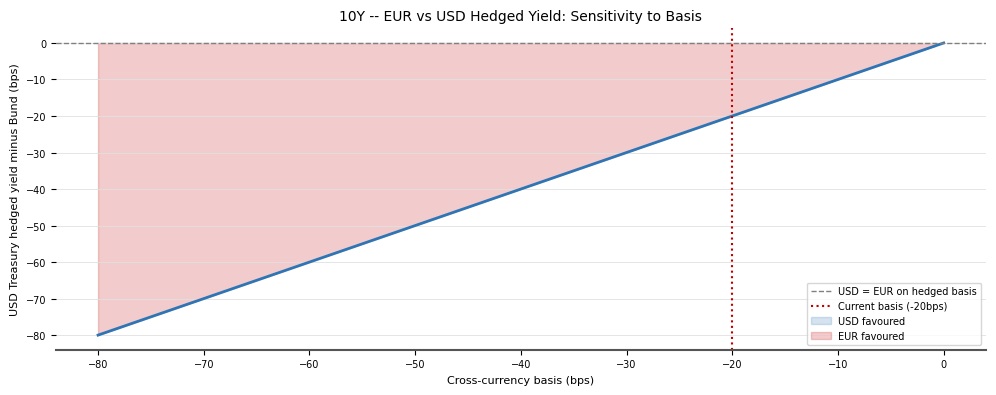

In [18]:
# ── hedged yield across basis scenarios ──────────────────────────────────────
# Show how the attractiveness of USD Treasuries changes
# as the cross-currency basis changes.

basis_scenarios = np.linspace(-80, 0, 100)   # basis from -80bps to 0
tenor_rv = '10Y'
eur_10y  = eur_yields[tenor_rv]
usd_10y  = usd_yields[tenor_rv]
rate_diff_10y = usd_10y - eur_10y

hedged_usd_10y = [usd_10y - (rate_diff_10y - b/100) for b in basis_scenarios]
spread_to_eur  = [h - eur_10y for h in hedged_usd_10y]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(basis_scenarios, [s * 100 for s in spread_to_eur], color=C1, linewidth=2)
ax.axhline(0, color='grey', linestyle='--', linewidth=1, label='USD = EUR on hedged basis')
ax.axvline(basis_bps, color=C4, linestyle=':', linewidth=1.5,
           label=f'Current basis ({basis_bps}bps)')
ax.fill_between(basis_scenarios,
                [s * 100 for s in spread_to_eur], 0,
                where=[s > 0 for s in spread_to_eur],
                color=C1, alpha=0.2, label='USD favoured')
ax.fill_between(basis_scenarios,
                [s * 100 for s in spread_to_eur], 0,
                where=[s < 0 for s in spread_to_eur],
                color=C4, alpha=0.2, label='EUR favoured')
ax.set_xlabel('Cross-currency basis (bps)')
ax.set_ylabel('USD Treasury hedged yield minus Bund (bps)')
ax.set_title('10Y -- EUR vs USD Hedged Yield: Sensitivity to Basis')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 8. Asset Allocation Signals -- Combining Indicators

A quantitative fixed income desk combines multiple signals into an
asset allocation framework. The goal is to systematically rank:

- **Duration:** should we be long or short overall rate risk?
- **Curve:** should we be positioned for flattening or steepening?
- **Credit:** should we overweight or underweight credit spread risk?
- **Country:** which sovereign markets offer the best risk-adjusted return?

**Signal construction:**
Each signal is normalised to a z-score relative to its own history.
A composite signal is a weighted average of the individual signals.
Position sizing scales with signal strength and is constrained by
risk limits (VaR, DV01 budget, tracking error budget).

**Carry and roll-down as signals:**
Carry is the yield earned by holding a bond for one period with no
change in rates. Roll-down is the additional return from the bond
moving along the curve as it ages (if the curve is upward sloping,
a 10Y bond becomes a 9Y bond after one year, which has a lower yield
and therefore a higher price):

$$Roll\text{-}down = (y_{T} - y_{T-1}) \times ModDuration$$

Total expected return over one period:

$$E[R] = Carry + Roll\text{-}down - Duration \times \Delta y$$

In [19]:
# ── carry and roll-down analysis ──────────────────────────────────────────────
# For each bond, compute the 1-year carry and roll-down.
# This is a key input to the asset allocation decision.

carry_roll_results = []
for _, row in rv_df.iterrows():
    # carry = yield (annual coupon minus funding cost)
    # funding cost ≈ OIS overnight rate
    funding_cost = ois_curve.zero_rate(0.25)  # 3M OIS as funding rate
    carry        = row['ytm'] - funding_cost

    # roll-down = change in yield as bond moves one year down the curve
    # estimate: (yield at current maturity) - (yield at maturity - 1Y)
    current_tenor = row['duration']
    rolled_tenor  = max(current_tenor - 1.0, 0.25)
    yield_current = nss_curve.zero_rate(current_tenor)
    yield_rolled  = nss_curve.zero_rate(rolled_tenor)
    roll_down     = (yield_current - yield_rolled) * row['duration']   # in %

    total_return_1y = carry + roll_down

    carry_roll_results.append({
        'name':           row['name'],
        'country':        row['country'],
        'duration':       row['duration'],
        'carry_bps':      carry * 100,
        'roll_down_bps':  roll_down * 100,
        'total_return_bps': total_return_1y * 100,
    })

cr_df = pd.DataFrame(carry_roll_results).sort_values('total_return_bps', ascending=False)

print("Carry and Roll-Down -- EUR Government Bonds (1Y horizon, no rate change)")
print(f"{'Bond':<25} {'Country':>8} {'Duration':>10} {'Carry':>10} {'Roll-down':>12} {'Total 1Y':>12}")
print("-" * 82)
for _, row in cr_df.iterrows():
    print(f"{row['name']:<25} {row['country']:>8} {row['duration']:>10.2f}y "
          f"{row['carry_bps']:>8.1f}bps {row['roll_down_bps']:>10.1f}bps {row['total_return_bps']:>10.1f}bps")

Carry and Roll-Down -- EUR Government Bonds (1Y horizon, no rate change)
Bond                       Country   Duration      Carry    Roll-down     Total 1Y
----------------------------------------------------------------------------------
Bund 2.5% 2046                  DE      15.20y    121.1bps       61.7bps      182.9bps
BTP 4.75% 2044                  IT      12.65y    107.5bps       69.6bps      177.1bps
OAT 3.5% 2035                   FR       7.56y     58.3bps       56.6bps      114.9bps
Bund 2.6% 2034                  DE       7.35y     56.0bps       54.7bps      110.7bps
OLO 3.3% 2034                   BE       7.03y     54.1bps       51.7bps      105.8bps
BTP 4.5% 2033                   IT       6.02y     46.3bps       40.0bps       86.3bps
OAT 3.0% 2032                   FR       5.88y     44.0bps       38.2bps       82.2bps
Bund 2.5% 2027                  DE       1.51y     13.3bps       40.2bps       53.6bps
Bund 2.5% 2030                  DE       4.06y     32.7bps       

In [20]:
# ── composite asset allocation signal ────────────────────────────────────────
# Combine three signals into a composite score:
#   1. Carry and roll-down (total return if rates unchanged)
#   2. Z-spread residual (cheapness vs own curve)
#   3. Duration-adjusted carry (carry per unit of rate risk)

# Merge the two dataframes
signal_df = rv_df[['name','country','duration','dv01','z_spread_bps','z_residual_bps']].copy()
signal_df = signal_df.merge(cr_df[['name','carry_bps','roll_down_bps','total_return_bps']],
                             on='name')

# Normalise each signal to z-score
def zscore(series):
    return (series - series.mean()) / series.std()

signal_df['signal_carry']    = zscore(signal_df['total_return_bps'])
signal_df['signal_rv']       = zscore(signal_df['z_residual_bps'].fillna(0))
signal_df['carry_per_dv01']  = signal_df['carry_bps'] / signal_df['duration']
signal_df['signal_efficiency'] = zscore(signal_df['carry_per_dv01'])

# Composite signal -- equal weighted
signal_df['composite'] = (
    0.40 * signal_df['signal_carry'] +
    0.35 * signal_df['signal_rv']    +
    0.25 * signal_df['signal_efficiency']
)

signal_df = signal_df.sort_values('composite', ascending=False)

print("Composite Asset Allocation Signal -- EUR Government Bonds")
print(f"{'Bond':<25} {'Country':>8} {'Carry sig':>12} {'RV sig':>10} {'Eff sig':>10} {'Composite':>12} {'Rank':>6}")
print("-" * 88)
for rank, (_, row) in enumerate(signal_df.iterrows(), 1):
    print(f"{row['name']:<25} {row['country']:>8} {row['signal_carry']:>+10.2f}σ "
          f"{row['signal_rv']:>+8.2f}σ {row['signal_efficiency']:>+8.2f}σ "
          f"{row['composite']:>+10.2f}σ {rank:>6}")

Composite Asset Allocation Signal -- EUR Government Bonds
Bond                       Country    Carry sig     RV sig    Eff sig    Composite   Rank
----------------------------------------------------------------------------------------
BTP 4.75% 2044                  IT      +1.72σ    -0.55σ    +0.97σ      +0.74σ      1
Bund 2.6% 2034                  DE      +0.41σ    +1.59σ    -0.45σ      +0.61σ      2
Bund 2.5% 2046                  DE      +1.84σ    -0.85σ    +0.11σ      +0.46σ      3
BTP 4.5% 2033                   IT      -0.08σ    +1.41σ    -0.33σ      +0.38σ      4
OAT 3.0% 2032                   FR      -0.16σ    +0.81σ    -0.66σ      +0.05σ      5
OLO 3.3% 2034                   BE      +0.31σ    -0.00σ    -0.34σ      +0.04σ      6
Bund 2.5% 2030                  DE      -0.87σ    +0.93σ    +0.23σ      +0.04σ      7
OAT 3.5% 2035                   FR      +0.49σ    -0.56σ    -0.31σ      -0.08σ      8
OAT 3.0% 2028                   FR      -1.01σ    -0.25σ    +1.46σ      -0.

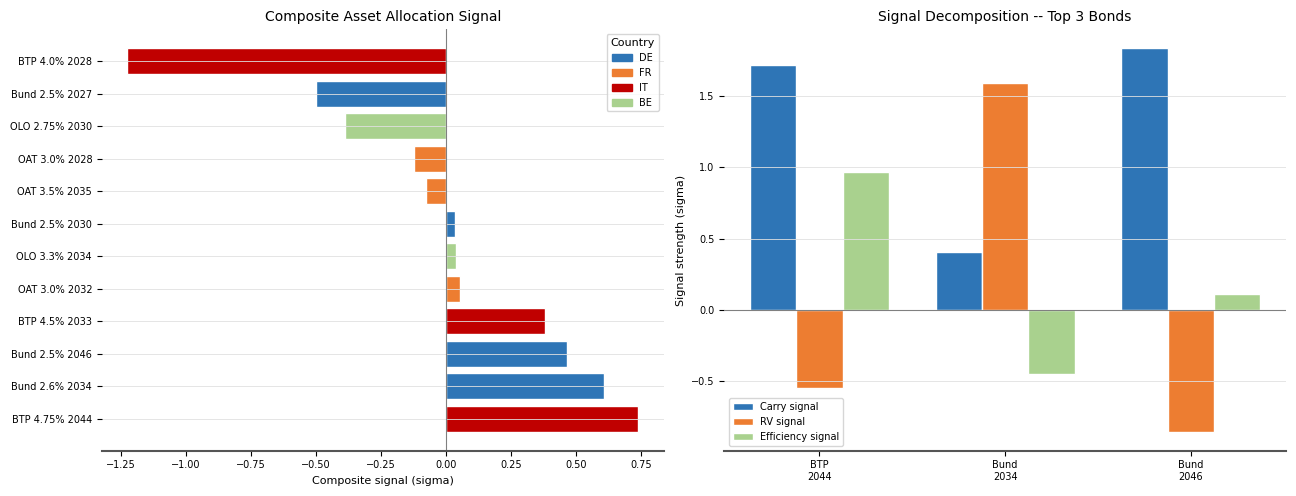

In [ ]:
# ── composite signal visualisation ───────────────────────────────────────────
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

# left: composite signal bar chart
colors_signal = [country_colors[c] for c in signal_df['country']]
bars = ax0.barh(signal_df['name'], signal_df['composite'],
                    color=colors_signal, edgecolor='white')
ax0.axvline(0, color='grey', linewidth=0.8)
ax0.set_xlabel('Composite signal (sigma)')
ax0.set_title('Composite Asset Allocation Signal')
ax0.spines['bottom'].set_color('#555555')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(color=country_colors[c], label=c) for c in ['DE','FR','IT','BE']]
ax0.legend(handles=legend_elements, title='Country')

# right: signal decomposition for top 3
top3 = signal_df.head(3)
x = np.arange(3)
w = 0.25
ax1.bar(x - w, top3['signal_carry'],     w, color=C1, label='Carry signal',    edgecolor='white')
ax1.bar(x,     top3['signal_rv'],         w, color=C2, label='RV signal',       edgecolor='white')
ax1.bar(x + w, top3['signal_efficiency'], w, color=C3, label='Efficiency signal',edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels([n.split(' ')[0] + '\n' + n.split(' ')[-1] for n in top3['name']], fontsize=7)
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.set_ylabel('Signal strength (sigma)')
ax1.set_title('Signal Decomposition -- Top 3 Bonds')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## Summary

<small> 

| Module | Methodology | Output |
|--------|------------|--------|
| Top-down curve analysis | Level, slope, curvature (butterfly) | Macro positioning signal |
| EUR gov RV | Z-spread vs OIS, residual to fitted curve | Cheap/rich bond identification |
| Curve trades | DV01-neutral flattener/steepener/butterfly | Duration-neutral P&L from curve shape |
| Cross-country spreads | Z-spread comparison across sovereigns | Bund vs OAT vs BTP positioning |
| Pair trading | Cointegration, hedge ratio, z-score signal | Entry/exit signals with DV01 sizing |
| EUR IG credit | Sector RV, OAS, rating-adjusted spread | Credit allocation signal |
| Multi-currency | Hedged yield, basis cost, CIP framework | EUR vs USD trade recommendation |
| Asset allocation | Composite signal (carry + RV + efficiency) | Ranked bond scorecard |

</small> 

**FRTB regulatory context:**
All positions generate GIRR delta sensitivities (key rate DV01 per tenor vertex)
reportable under CRR3 Article 325. IG corporate positions additionally generate
CSR-NS delta (CS01). Cross-country basis swaps fall under GIRR.

---
*Notebook QRE-72 | Module 1 -- Yield Curves and Asset Pricing | Sprint 5*  
*Regulation: CRR3 FRTB SA, UCITS global exposure, AIFMD leverage monitoring*